## Entrega 2 — Comparación de Familias y Validación
## Sistema de Recomendación de Películas: MovieLens 100K

**Institución:** EAFIT  
**Curso:** Aprendizaje de Máquina Aplicado  
**Profesor:** Marco Teran  
**Fecha límite:** 14/05/2026  
**Dataset:** MovieLens 100K — GroupLens Research
**Integrantes:** 
  - Jerónimo Pérez Baquero (jperezb5@eafit.edu.co)
  - David Grisales Posada (dgrisalesp@eafit.edu.co)
  - Esteban Vergara Giraldo (evergarag@eafit.edu.co)

---

### Preguntas centrales
- ¿Es posible predecir el rating (1–5) que un usuario le daría a una película que no ha visto?
- ¿Cuál de las siguientes tres familias de modelos que veremos es la más efectiva para este problema?
  - **KNN (K nearest neighbors)**: Es el "caja negra" que encuentra patrones ocultos en las calificaciones, pero no sabe qué es una película de acción o quién es un técnico de 24 años.
  - **SVD (singular value decomposition)**: Es el modelo "social". Busca personas similares a ti. Es muy fácil de explicar ("Te recomendamos esto porque a tu vecino le gustó").
  - **Lasso y Ridge (linear regressions)**: Son los modelos  "basado en contenido". Aquí es donde le sacamos jugo a los archivos Users y Movies, con toda la data que venía en ellos.

### Importación de librerías y configuración

In [1]:
!pip install -r ../requirements.txt

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp311-cp311-macosx_10_9_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached t

In [3]:
%pip install --upgrade pip setuptools wheel
%pip install scikit-surprise

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [28]:
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Lasso, Ridge
from surprise import SVD, KNNWithMeans, Dataset, Reader, accuracy

# from surprise.model_selection import train_test_split as surprise_split

FIXED_RANDOM_SEED = 42

# Configuration
warnings.filterwarnings("ignore")
np.random.seed(FIXED_RANDOM_SEED)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid", palette="muted")

print("Libraries loaded successfully ✓")

Libraries loaded successfully ✓


In [29]:
# Path to raw data
DATA_PATH = "../data/raw/ml-100k/"

# Ratings
ratings = pd.read_csv(
    DATA_PATH + "u.data", sep="\t", names=["user_id", "item_id", "rating", "timestamp"]
)

# Users
users = pd.read_csv(
    DATA_PATH + "u.user",
    sep="|",
    names=["user_id", "age", "gender", "occupation", "zip_code"],
)

# Movies
movie_cols = [
    "item_id",
    "title",
    "release_date",
    "video_release_date",
    "imdb_url",
    "unknown",
    "Action",
    "Adventure",
    "Animation",
    "Children",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western",
]

movies = pd.read_csv(
    DATA_PATH + "u.item", sep="|", encoding="latin-1", names=movie_cols
)

print(f"Ratings:  {ratings.shape[0]:,} rows × {ratings.shape[1]} columns")
print(f"Users:    {users.shape[0]:,} rows × {users.shape[1]} columns")
print(f"Movies:   {movies.shape[0]:,} rows × {movies.shape[1]} columns")

Ratings:  100,000 rows × 4 columns
Users:    943 rows × 5 columns
Movies:   1,682 rows × 24 columns


In [6]:
ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [7]:
users.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [8]:
movies.head()

,item_id,title,release_date,video_release_date,imdb_url,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


## Conocimientos previos (gracias al EDA de la entrega 1)

### Calidad de datos (nulos, duplicados)

- **Ratings**: sin nulos, sin duplicados, rango válido (1–5). ✓
- **Users**: sin nulos en ninguna columna. ✓
- **Movies**:
  - `video_release_date`: 1,682/1,682 nulos
  - `release_date`: 1 nulo

Entendido. He ajustado el formato para que cada punto tenga la estructura de **Subtítulo: Texto**, manteniendo la decoración de Markdown para facilitar la lectura:

### Distribución de datos

- **Sesgo de positividad en Ratings:** Los ratings muestran sesgo de positividad — la media (~3.5) está por encima del punto medio de la escala (3.0). Ratings 3 y 4 concentran la mayoría de las interacciones. Esto implica que un baseline de media global ya captura parte del patrón.
- **Sparsity y el fenómeno de "Cola Larga":** La matriz usuario–película tiene una sparsity del 93.70% — solo 100,000 de 1,586,126 combinaciones posibles tienen rating. Ambas distribuciones muestran cola larga: pocos usuarios y pocas películas concentran la mayoría de interacciones. Esto introduce el problema de **cold start**: el modelo tendrá menor precisión para usuarios con pocas calificaciones y películas poco vistas.
- **Perfil demográfico y representatividad:** El perfil demográfico muestra sesgo significativo — aproximadamente 3 de cada 4 usuarios son hombres, la ocupación más frecuente es estudiante, y aunque el rango de edad es amplio (7–73 años), la mediana es 31. La media (34.1) está jalada por usuarios mayores. El modelo aprenderá principalmente de las preferencias de hombres jóvenes, lo que limita su generalización a otros perfiles demográficos.
- **Preferencia generacional:** El dataset refleja una preferencia generacional: la mayoría de los ratings se concentran en estrenos de los años 90. Dado que el perfil predominante es el de estudiantes jóvenes, existe una correlación clara entre la juventud del público y el consumo de cine reciente. Esto demuestra que, para este grupo, la relevancia de una película está fuertemente ligada a su fecha de lanzamiento.
- **Tendencia vs. Aclamación:** Existe una distinción clara entre lo que es tendencia y lo que es aclamado. Aunque los usuarios muestran una inclinación natural hacia el cine reciente, los datos confirman que la calidad no tiene fecha de caducidad. Películas con menor frecuencia de voto, pero mayor antigüedad, mantienen promedios superiores, lo que sugiere que el público sigue otorgando un valor especial a los clásicos que han logrado trascender su época.
- **Volumen histórico:** La base de datos refleja un boom del cine en los años 90's, ya que allí se concentra la mayor parte de la información sobre películas.
- **Recepción y Nichos de Mercado:** Se observa que la abundancia de lanzamientos no garantiza la mejor recepción. Aunque el cine de la época apostaba masivamente por el drama y la comedia, los usuarios mostraron un mayor aprecio por categorías con menor volumen de producción. Esto sugiere que los géneros minoritarios cuentan con un público más fiel y entusiasta, cuya valoración positiva compensa la falta de cantidad, demostrando que el interés de los usuarios es más profundo en secciones específicas de la industria que en el contenido de consumo masivo.

## Baseline

Este **Baseline** actúa como el umbral mínimo de éxito: cualquier modelo que pretenda solucionar el problema de recomendación debe ser significativamente más preciso que este cálculo básico (calculado en el primer notebook).

- **Definición del modelo:** Hemos definido el Baseline de manera puramente estadística como el **promedio global de las reseñas**. Matemáticamente, esto significa predecir siempre el mismo valor para cualquier combinación de usuario y película:

$$\hat{y}_i = \bar{y} = 3.53$$


- **Origen de los datos:** Siguiendo la exploración detallada en nuestro **primer notebook**, sabemos que el dataset presenta un marcado sesgo de positividad. El valor de $3.53$ (obtenido del promedio del conjunto de entrenamiento) ya captura esta tendencia central del comportamiento de los usuarios en MovieLens 100k.
- **Justificación:** El uso de una media global es un estándar en la industria. Si un modelo sofisticado (como SVD o Lasso) no logra reducir el error respecto a este promedio constante, significa que no está capturando patrones útiles de los datos o que el ruido es demasiado alto. En resumen: si no es mejor que el promedio, el modelo no es útil.
- **Métricas a superar:** Basándonos en los cálculos realizados anteriormente sobre el conjunto de prueba, nuestro objetivo en este notebook es superar el desempeño de esta línea base. Cualquier mejora en el **RMSE** o **MAE** respecto a estos valores será el indicador real de que nuestros modelos están aprendiendo relaciones valiosas entre los metadatos y las preferencias de los usuarios.
  - **RMSE = 1.1253:** En promedio, las predicciones del baseline se desvían del rating real en ±1.13 puntos en la escala 1–5. Esto significa que si el usuario califica una película con 4 estrellas, el baseline (que siempre predice 3.53) errará en aproximadamente 1.13 puntos de media.
  - **MAE = 0.9008:** El error promedio sin considerar dirección es de 0.90 puntos. Este valor más bajo que RMSE indica que hay pocas predicciones extremadamente erróneas — la mayoría de errores se concentra en una banda moderada alrededor de la media.


## Preprocesamiento y limpieza de datos

Tras analizar la naturaleza de los datos y los requerimientos de los modelos seleccionados (SVD, KNN, Lasso y Ridge), se han tomado las siguientes decisiones estratégicas:

### 1. Limpieza y Selección de Características (Feature Selection)

- **Ratings y Users:** No presentan valores nulos ni problemas de integridad, por lo que se mantienen en su estado original.
- **Movies:**
- **Eliminación de ruido:** Se descartan `video_release_date` (100% de valores nulos) e `imdb_url` y `title`, ya que no poseen valor predictivo para los modelos lineales o matriciales.
- **Ingeniería de variables:** De la columna `release_date` se extraerá únicamente el **año**, tratándolo como una variable numérica para capturar tendencias temporales (ej. películas clásicas vs. modernas). Los registros nulos en esta columna (mínimos) se imputarán con la mediana.
- **Géneros:** Se conservan las 19 columnas de género (Action, Sci-Fi, etc.) que ya vienen pre-codificadas como variables binarias (0 y 1).

### 2. Transformación de Datos (Encoding y Scaling)

Para los modelos de regresión (Lasso y Ridge), aplicaremos un tratamiento diferenciado mediante un `ColumnTransformer`:

- **Variables Categóricas (`gender`, `occupation`):** Se aplicará **One-Hot Encoding**. Esto transforma categorías de texto en columnas binarias independientes, evitando que el modelo asuma un orden jerárquico inexistente (como pensar que un "técnico" es mayor que un "escritor").
- **Estandarización (Z-Scaling):** Se aplicará `StandardScaler` **únicamente a las variables numéricas continuas** (edad y año de lanzamiento). Esto asegura que Lasso no penalice más a una variable solo por tener una escala mayor (ej. la edad de 50 vs. el género de 1).
- **Regla de Oro para Binarios:** Las variables resultantes del One-Hot Encoding y los géneros de las películas **no se estandarizan**. Se mantendrán como valores puros de 0 y 1 para preservar su significado matemático de "activación" dentro del modelo Lasso.

### 3. Estrategia de Validación y Prevención de Fuga (Data Leakage)

- **División de Datos:** Utilizaremos una partición de **60% Entrenamiento, 20% Validación y 20% Testeo**. Dado que las distribuciones de ratings por usuario no son uniformes, esta proporción nos permite tener un set de validación robusto para el ajuste de hiperparámetros ($\alpha$ en Lasso/Ridge) y un set de testeo representativo para el veredicto final.
- **Integridad del Escalador:** Para evitar el *data leakage*, el escalador (`StandardScaler`) se ajustará (`fit`) **exclusivamente con los datos de entrenamiento**. Posteriormente, esa misma transformación se aplicará (`transform`) a los sets de validación y testeo. Esto garantiza que el modelo no tenga información previa sobre la distribución o el rango de los datos que usaremos para evaluarlo.
- **Consistencia de random seed** La semilla aleatoria quedará fija en 42, guardado en la constante `FIXED_RANDOM_SEED`, para todas las occurrencias en donde se requiera una. Ya se ha fijado en `np.random.seed(FIXED_RANDOM_SEED)` en el primer bloque de código, y se fijará con `random_state=FIXED_RANDOM_SEED` para todas las operaciones de división y modelado, asegurando reproducibilidad y comparabilidad entre modelos.

In [30]:
# Extract release year from release_date
movies["release_year"] = pd.to_datetime(movies["release_date"], errors="coerce").dt.year

# Check the result
print(movies[["title", "release_date", "release_year"]].head(10))
print(f"\nNulls in release_year: {movies['release_year'].isnull().sum()}")
print(
    f"Year range: {movies['release_year'].min():.0f} – {movies['release_year'].max():.0f}"
)

                                               title release_date  \
0                                   Toy Story (1995)  01-Jan-1995   
1                                   GoldenEye (1995)  01-Jan-1995   
2                                  Four Rooms (1995)  01-Jan-1995   
3                                  Get Shorty (1995)  01-Jan-1995   
4                                     Copycat (1995)  01-Jan-1995   
5  Shanghai Triad (Yao a yao yao dao waipo qiao) ...  01-Jan-1995   
6                              Twelve Monkeys (1995)  01-Jan-1995   
7                                        Babe (1995)  01-Jan-1995   
8                            Dead Man Walking (1995)  01-Jan-1995   
9                                 Richard III (1995)  22-Jan-1996   

   release_year  
0        1995.0  
1        1995.0  
2        1995.0  
3        1995.0  
4        1995.0  
5        1995.0  
6        1995.0  
7        1995.0  
8        1995.0  
9        1996.0  

Nulls in release_year: 1
Year range: 1922

In [31]:
# Fill the single null with the median year
median_year = movies["release_year"].median()
movies["release_year"] = movies["release_year"].fillna(median_year)

print(f"Null filled with median year: {median_year:.0f}")
print(f"Nulls remaining: {movies['release_year'].isnull().sum()}")

Null filled with median year: 1995
Nulls remaining: 0


In [32]:
# We prepare the data for Lasso and Ridge. Master table
# We merge Ratings + Users + Movies
df_master = ratings.merge(users, on="user_id").merge(movies, on="item_id")

# We separate features and target
X = df_master.drop("rating", axis=1)
y = df_master["rating"]

print(f"Feature matrix X: {X.shape[0]:,} rows × {X.shape[1]} columns")
print(f"Target vector y: {y.shape[0]:,} rows")

Feature matrix X: 100,000 rows × 31 columns
Target vector y: 100,000 rows


In [33]:
# We divide the data into train, validation and test

# First 60% train and 40% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=FIXED_RANDOM_SEED
)

# We divide the 40% temporal into 20% validation and 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=FIXED_RANDOM_SEED
)

print(f"Train: {X_train.shape[0]:,} rows")
print(f"Validation: {X_val.shape[0]:,} rows")
print(f"Test: {X_test.shape[0]:,} rows")

Train: 60,000 rows
Validation: 20,000 rows
Test: 20,000 rows


In [34]:
# Lasso and Ridge specific preprocessing:

# Let's clean the unwanted fields. This preprocessing step is specially necessary for Lasso and Ridge. KNN and SVD will work with the original data, as they are designed to handle it without problem.

# We define the columns (the ones we selected before after filtering the unuseful ones)
features_num = ["age"]
features_cat = ["gender", "occupation"]
features_genres = [
    "Action",
    "Adventure",
    "Animation",
    "Children",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western",
]

# Both Lasso and Ridge can use a special preprocessing step. We define the preprocessor following those rules about the numerical features, the categorical features and the genres (which are already one-hot encoded, so we will just pass them through).
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features_num),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), features_cat),
        ("genres", "passthrough", features_genres),
    ],
    remainder="drop",  # We drop the remaining columns (IDs, Zip Code, Titles, etc.)
)

print("Preprocessor defined successfully ✓")

Preprocessor defined successfully ✓


In [43]:
# Surprise (SVD and KNN) specific preprocessing:

reader = Reader(rating_scale=(1, 5))

# Dataset Object for GridSearchCV
train_data = Dataset.load_from_df(
    df_master.loc[X_train.index, ["user_id", "item_id", "rating"]],
    reader,
)

# We create datasets for each partition (only fields being user_id, item_id and rating)
train_surp = Dataset.load_from_df(
    df_master.loc[X_train.index, ["user_id", "item_id", "rating"]], reader
).build_full_trainset()

val_surp = list(
    df_master.loc[X_val.index, ["user_id", "item_id", "rating"]].itertuples(
        index=False, name=None
    )
)
test_surp = list(
    df_master.loc[X_test.index, ["user_id", "item_id", "rating"]].itertuples(
        index=False, name=None
    )
)

print("Surprise datasets created successfully ✓")

Surprise datasets created successfully ✓


## Lasso and Ridge: Regression Models

In [156]:
# That alpha hyperparameter can be optimized later with optuna or smt
lasso_pipe = Pipeline(
    [
        ("pre", preprocessor),
        ("model", Lasso(alpha=0.001)),  # Small alpha to not kill too many variables
    ]
)

ridge_pipe = Pipeline(
    [
        ("pre", preprocessor),
        ("model", Ridge(alpha=10.0)),  # Default alpha for Ridge
    ]
)

In [135]:
from sklearn.model_selection import GridSearchCV

lasso_params = {
    "model__alpha": [0.001, 0.005, 0.01, 0.05, 0.1],
}

lasso_grid = GridSearchCV(lasso_pipe, lasso_params, cv=3, scoring="neg_root_mean_squared_error",
                          return_train_score=True)
lasso_grid.fit(X_train, y_train)
print(f"Best Lasso alpha: {lasso_grid.best_params_['model__alpha']}")
print(f"Best Lasso RMSE: {-lasso_grid.best_score_:.4f}")

Best Lasso alpha: 0.001
Best Lasso RMSE: 1.1014


In [136]:
import matplotlib.pyplot as plt

def plot_search_results(grid_search, param_name, title):
    results = grid_search.cv_results_
    # Get the parameter values
    params = [p[param_name] for p in results['params']]
    
    # Convert Negative MSE to positive RMSE
    train_rmse = np.sqrt(np.abs(results['mean_train_score']))
    test_rmse = np.sqrt(np.abs(results['mean_test_score']))
    
    plt.figure(figsize=(8, 5))
    plt.plot(params, train_rmse, label='Train RMSE', marker='o', linestyle='--')
    plt.plot(params, test_rmse, label='Test RMSE', marker='o', linewidth=2)
    
    plt.xscale('log') # Alphas are usually tested on log scale (0.001, 0.01, 0.1)
    plt.xlabel(f'Hyperparameter: {param_name}')
    plt.ylabel('RMSE (Lower is Better)')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


In [137]:
ridge_params = {
    "model__alpha": [0.1, 1.0, 10.0, 100.0],

}
ridge_grid = GridSearchCV(ridge_pipe, ridge_params, cv=3, scoring="neg_root_mean_squared_error",
                          return_train_score=True)
ridge_grid.fit(X_train, y_train)
print(f"Best Ridge alpha: {ridge_grid.best_params_['model__alpha']}")
print(f"Best Ridge RMSE: {-ridge_grid.best_score_:.4f}")    

Best Ridge alpha: 10.0
Best Ridge RMSE: 1.1009


In [158]:
# Training for lasso
lasso_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

In [160]:
# Training for Ridge
ridge_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

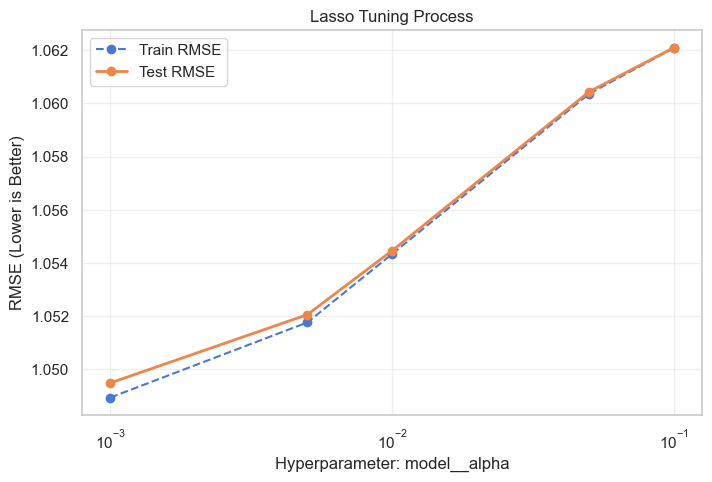

In [139]:
plot_search_results(lasso_grid, 'model__alpha', 'Lasso Tuning Process')

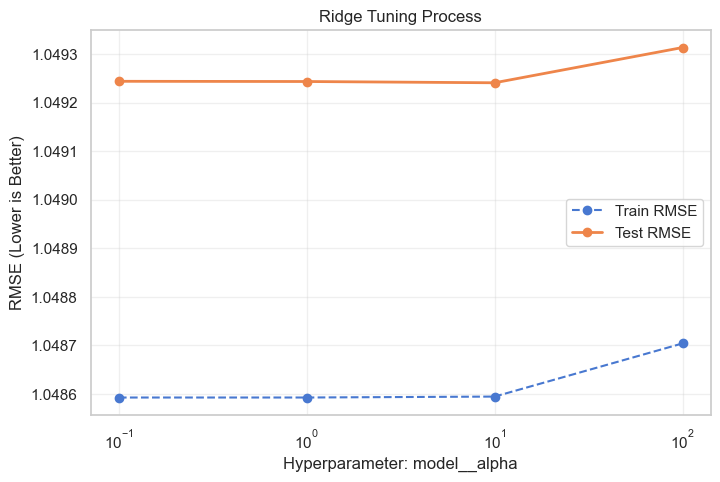

In [140]:
plot_search_results(ridge_grid, 'model__alpha', 'Ridge Tuning Process')

### Lasso coefficients graph

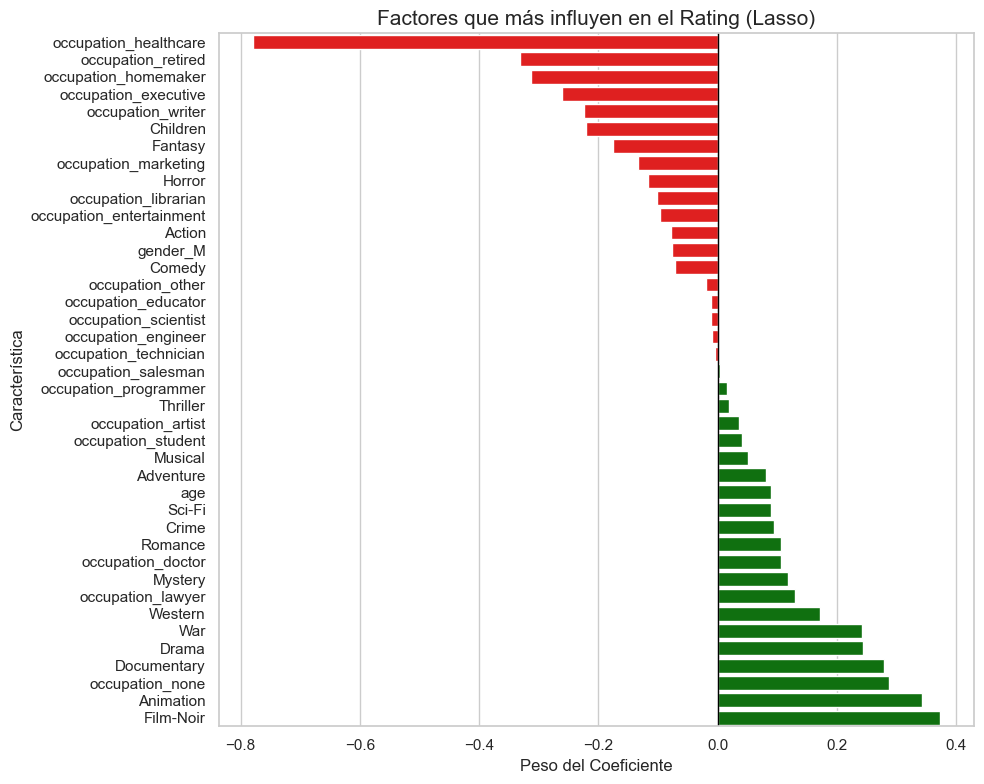

In [141]:
# We extract the coefficients from Lasso to see which features survived and their importance. We also get the feature names after preprocessing to make the graph more interpretable.
ohe_names = (
    lasso_pipe.named_steps["pre"]
    .named_transformers_["cat"]
    .get_feature_names_out(features_cat)
)
feature_names = features_num + list(ohe_names) + features_genres

coefs = lasso_pipe.named_steps["model"].coef_

# We create a DataFrame to plot the coefficients, filtering only the ones that survived (coef != 0) and sorting them by their value
df_coefs = pd.DataFrame({"Feature": feature_names, "Coef": coefs})
df_coefs = df_coefs[df_coefs["Coef"] != 0].sort_values(
    by="Coef"
)  # Only the ones that survived

plt.figure(figsize=(10, 8))
colors = ["red" if x < 0 else "green" for x in df_coefs["Coef"]]
sns.barplot(data=df_coefs, x="Coef", y="Feature", palette=colors)
plt.title("Factores que más influyen en el Rating (Lasso)", fontsize=15)
plt.xlabel("Peso del Coeficiente")
plt.ylabel("Característica")
plt.axvline(0, color="black", lw=1)
plt.tight_layout()
plt.savefig("../figures/09_lasso_coefficients.png", bbox_inches="tight")
plt.show()

¿Cómo interpretar la gráfica?

- Barras Verdes (Positivas): Son las características que "suben" la calificación. Por ejemplo, si Drama es positivo, significa que, en promedio, a la gente de este dataset le suelen gustar más las películas de drama que otros géneros.

- Barras Rojas (Negativas): Son las que bajan el rating. Si Horror está en rojo, indica que esas películas tienden a recibir notas más bajas.

- Variables Ausentes: Si una variable que metimos (como alguna ocupación específica) no aparece en la gráfica, es porque Lasso le dio un coeficiente de exactamente cero. El modelo decidió que esa información no ayudaba a predecir el rating.

## KNN (K-Nearest Neighbors): Instance-based learning/Colaborative Filtering

In [142]:
model_knn = KNNWithMeans(
    k=80,
    min_k=1,
    sim_options={"name": "cosine", "user_based": False, "min_support": 1}, verbose=False
)
model_knn.fit(train_surp)
print()

### Hyperparameter optimization for KNN

In [146]:
from surprise.model_selection import GridSearchCV
param_grid = {
    "k": [20, 40, 60,80],
    "min_k": [1, 5, 10],
    "sim_options":{
        "name": ["cosine", "pearson"],
        "user_based": [True, False],
        "min_support": [1, 5, 10]
    }
}

grid_search = GridSearchCV(KNNWithMeans, param_grid, measures=["rmse", "mae"], cv=3)
grid_search.fit(train_data)
print("Best RMSE:", grid_search.best_score["rmse"])
print("Best MAE:", grid_search.best_score["mae"])
print("Best parameters:", grid_search.best_params["rmse"])

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing th

In [147]:
print("Best RMSE:", grid_search.best_score["rmse"])
print("Best MAE:", grid_search.best_score["mae"])
print("Best parameters:", grid_search.best_params["rmse"])

Best RMSE: 0.967524732771448
Best MAE: 0.761052977755372
Best parameters: {'k': 80, 'min_k': 1, 'sim_options': {'name': 'cosine', 'user_based': False, 'min_support': 1}}


param_min_k        1         5         10
param_k                                  
20           0.981240  0.981854  0.983829
40           0.969857  0.970479  0.972477
60           0.967663  0.968286  0.970289
80           0.967525  0.968147  0.970151


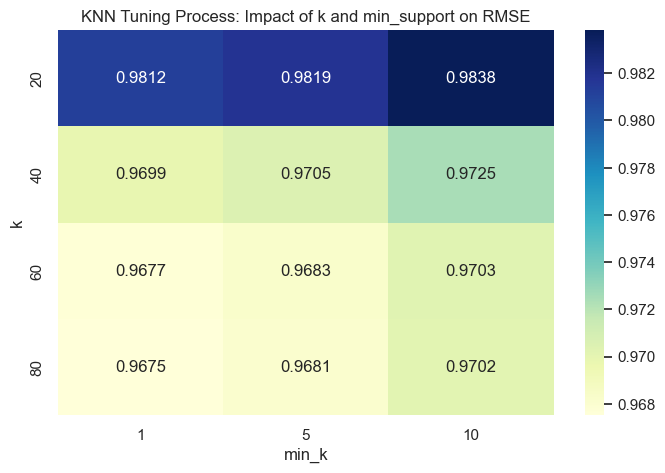

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



gs_knn = pd.DataFrame(grid_search.cv_results)
best_strategy_df = gs_knn[
    (gs_knn['param_sim_options'].apply(lambda x: x['user_based'] == False)) &
    (gs_knn['param_sim_options'].apply(lambda x: x['name'] == 'cosine')) &
    (gs_knn['param_sim_options'].apply(lambda x: x['min_support'] == 1))
]
pivot = best_strategy_df.pivot_table(index='param_k', columns='param_min_k', values="mean_test_rmse")
print(pivot)
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt=".4f")
plt.title('KNN Tuning Process: Impact of k and min_support on RMSE')
plt.xlabel('min_k')
plt.ylabel('k')
plt.show()

## SVD (Singular Value Decomposition): Latent factor models

In [152]:
model_svd = SVD(
    n_factors=150,
    n_epochs=30,
    lr_all=0.01,
    reg_all=0.1,
    random_state=FIXED_RANDOM_SEED)
model_svd.fit(train_surp)

### Hyperparameter Optimization for SVD

In [164]:
from surprise.model_selection import GridSearchCV

param_grid_svd = {
    "n_factors": [50, 100, 150], 
    "n_epochs": [10, 20, 30], 
    "lr_all": [0.002, 0.005, 0.01], 
    "reg_all": [0.01, 0.02, 0.1],
    "random_state": [FIXED_RANDOM_SEED] 
}

gs_svd = GridSearchCV(SVD, param_grid_svd, measures=["rmse", "mae"], cv=3)
gs_svd.fit(train_data)

# Results
print(f"Best SVD RMSE: {gs_svd.best_score['rmse']:.4f}")
print(f"Best SVD Params: {gs_svd.best_params['rmse']}")

Best SVD RMSE: 0.9462
Best SVD Params: {'n_factors': 50, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1, 'random_state': 42}


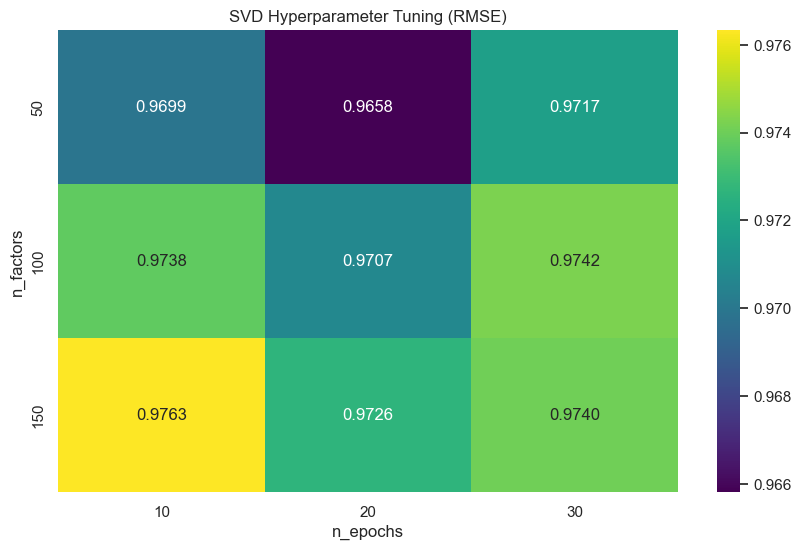

In [165]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_results = pd.DataFrame(gs_svd.cv_results)
pivot_table = df_results.pivot_table(
    index="param_n_factors",
    columns="param_n_epochs",
    values="mean_test_rmse",
    aggfunc="mean",
)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap="viridis")
plt.title("SVD Hyperparameter Tuning (RMSE)")
plt.xlabel("n_epochs")
plt.ylabel("n_factors")
plt.show()

## Comparativa final en RMSE

In [166]:
def get_rmse(model, X_data, y_true, is_surprise=False):
    if is_surprise:
        preds = model.test(X_data)
        return np.sqrt(
            mean_squared_error([p.r_ui for p in preds], [p.est for p in preds])
        )
    else:
        preds = model.predict(X_data).clip(1, 5)
        return np.sqrt(mean_squared_error(y_true, preds))


print("\n=== RESULTADOS FINALES (RMSE EN TEST) ===")
print(f"Lasso: {get_rmse(lasso_pipe, X_test, y_test):.4f}")
print(f"Ridge: {get_rmse(ridge_pipe, X_test, y_test):.4f}")
print(f"SVD  : {get_rmse(model_svd, test_surp, None, True):.4f}")
print(f"KNN  : {get_rmse(model_knn, test_surp, None, True):.4f}")


=== RESULTADOS FINALES (RMSE EN TEST) ===
Lasso: 1.0986
Ridge: 1.0978
SVD  : 0.9214
KNN  : 0.9464


In [167]:
results = []

# Evaluación Lasso
y_pred_lasso = lasso_pipe.predict(X_test).clip(1, 5)  # Forzamos rango 1-5
results.append(["Lasso", root_mean_squared_error(y_test, y_pred_lasso)])

# Evaluación Ridge
y_pred_ridge = ridge_pipe.predict(X_test).clip(1, 5)
results.append(["Ridge", root_mean_squared_error(y_test, y_pred_ridge)])

# Evaluación SVD
pred_svd = model_svd.test(test_surp)
results.append(["SVD", accuracy.rmse(pred_svd, verbose=False)])

# Evaluación KNN
pred_knn = model_knn.test(test_surp)
results.append(["KNN", accuracy.rmse(pred_knn, verbose=False)])

# Evaluación baseline
y_pred_baseline = np.full_like(y_test, y_test.mean())
results.append(["Baseline", root_mean_squared_error(y_test, y_pred_baseline)])

# --- MOSTRAR RESULTADOS ---
df_results = pd.DataFrame(results, columns=["Modelo", "RMSE"]).sort_values(by="RMSE")
print("\n=== COMPARATIVA DE MODELOS (RMSE) ===")
print(df_results)

print(
    "\nWinner is:",
    df_results.iloc[0]["Modelo"],
    "with RMSE =",
    df_results.iloc[0]["RMSE"],
)


=== COMPARATIVA DE MODELOS (RMSE) ===
     Modelo      RMSE
2       SVD  0.921398
3       KNN  0.946423
1     Ridge  1.097825
0     Lasso  1.098636
4  Baseline  1.245251

Winner is: SVD with RMSE = 0.9213984702915217


## Interpretación de resultados y conclusiones

### 1. El dominio de los Modelos Colaborativos (SVD y KNN)

Tanto **SVD (0.9214)** como **KNN (0.9464)** tienen los errores más bajos. Esto es normal porque estos modelos se enfocan en la **matriz de interacciones**.

* **SVD** suele ser el ganador porque es capaz de capturar "conceptos abstractos" (factores latentes). Por ejemplo, puede detectar que a un usuario le gustan las películas de "héroes incomprendidos" aunque esa etiqueta no exista en los metadatos.
* **KNN** se queda cerca porque aprovecha que los humanos somos seres de hábitos: si a 20 personas parecidas a ti les gustó algo, es muy probable que a ti también.

### 2. La limitación de los Modelos Lineales (Lasso y Ridge)

Los errores en **Lasso (1.0986)** y **Ridge (1.0978)** son más altos (peores) que los de SVD y KNN. Esto sucede por un fenómeno llamado **"Content-Only Limitation"**:

* Estos modelos están tratando de predecir el rating basándose *únicamente* en etiquetas fijas (edad, género, ocupación).
* **El problema:** Dos hombres de 25 años que son estudiantes pueden tener gustos radicalmente distintos. Lasso y Ridge intentarán darles la misma predicción porque sus "características" son iguales, mientras que SVD verá que uno califica cine arte y el otro cine de acción.
* Lasso y Ridge son "miopes" ante el gusto personal que no está escrito en el perfil demográfico.

### 3. Comparación con el Baseline

Si recordamos que el **Baseline** (el promedio global) suele rondar un RMSE de **1.12 - 1.15** en este dataset:

* Los modelos de regresión (**~1.10**) apenas mejoran un poco al promedio. Esto indica que los metadatos (edad, ocupación) ayudan, pero no son tan potentes como el historial de votos.
* Los modelos colaborativos (**~0.95**) dan un salto de calidad enorme. Bajar de 1.10 a 0.95 es una mejora muy significativa en la experiencia de un usuario.

### 4. ¿Por qué Ridge le ganó a Lasso?

Se puede notar que **Ridge (1.0978)** es ligeramente mejor que **Lasso (1.0986)**.

* Lasso es muy agresivo y elimina variables (las pone en cero).
* Ridge mantiene todas, aunque les dé un peso pequeño. En datasets pequeños como MovieLens 100K, a veces tener un poco de información de cada variable (Ridge) es mejor que descartar variables por completo (Lasso).

### TL;DR:

> "Los resultados confirman la superioridad del **filtrado colaborativo (SVD)** sobre los modelos basados en **metadatos (Lasso/Ridge)**. Mientras que SVD logra capturar la complejidad de los gustos individuales con un RMSE de 0.92, los modelos lineales se ven limitados por el hecho de que variables demográficas como la edad o la ocupación no son predictores absolutos del gusto cinematográfico, logrando apenas superar el desempeño del Baseline global."